In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
df = pd.read_csv("twitter_human_bots_dataset.csv")

In [23]:
print("shape=", df.shape)
df.head()


shape= (37438, 20)


,Unnamed: 0,created_at,default_profile,default_profile_image,description,favourites_count,followers_count,friends_count,geo_enabled,id,lang,location,profile_background_image_url,profile_image_url,screen_name,statuses_count,verified,average_tweets_per_day,account_age_days,account_type
0,0,2016-10-15 21:32:11,False,False,"Blame @xaiax, Inspired by @MakingInvisible, us...",4,1589,4,False,787405734442958848,en,unknown,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/7874121826...,best_in_dumbest,11041,False,7.870,1403,bot
1,1,2016-11-09 05:01:30,False,False,Photographing the American West since 1980. I ...,536,860,880,False,796216118331310080,en,Estados Unidos,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/8023296328...,CJRubinPhoto,252,False,0.183,1379,human
2,2,2017-06-17 05:34:27,False,False,Scruffy looking nerf herder and @twitch broadc...,3307,172,594,True,875949740503859204,en,"Los Angeles, CA",http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/1278890453...,SVGEGENT,1001,False,0.864,1159,human
3,3,2016-07-21 13:32:25,True,False,Wife.Godmother.Friend.Feline Fanatic! Assistan...,8433,517,633,True,756119643622735875,en,"Birmingham, AL",NaN,http://pbs.twimg.com/profile_images/1284884924...,TinkerVHELPK5,1324,False,0.889,1489,human
4,4,2012-01-15 16:32:35,False,False,Loan coach at @mancity & Aspiring DJ,88,753678,116,True,464781334,en,"England, United Kingdom",http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/9952566258...,JoleonLescott,4202,True,1.339,3138,human


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37438 entries, 0 to 37437
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    37438 non-null  int64  
 1   created_at                    37438 non-null  object 
 2   default_profile               37438 non-null  bool   
 3   default_profile_image         37438 non-null  bool   
 4   description                   30181 non-null  object 
 5   favourites_count              37438 non-null  int64  
 6   followers_count               37438 non-null  int64  
 7   friends_count                 37438 non-null  int64  
 8   geo_enabled                   37438 non-null  bool   
 9   id                            37438 non-null  int64  
 10  lang                          29481 non-null  object 
 11  location                      37434 non-null  object 
 12  profile_background_image_url  32939 non-null  object 
 13  p

In [25]:
df['account_type'].value_counts()
df['account_type'].value_counts(normalize = True)

account_type
human    0.668118
bot      0.331882
Name: proportion, dtype: float64

In [26]:
df.isnull().sum()

Unnamed: 0                         0
created_at                         0
default_profile                    0
default_profile_image              0
description                     7257
favourites_count                   0
followers_count                    0
friends_count                      0
geo_enabled                        0
id                                 0
lang                            7957
location                           4
profile_background_image_url    4499
profile_image_url                  1
screen_name                        0
statuses_count                     0
verified                           0
average_tweets_per_day             0
account_age_days                   0
account_type                       0
dtype: int64

#### features with null values: Description, Lang, profile_background_image_url

In [27]:
df.describe()

,Unnamed: 0,favourites_count,followers_count,friends_count,id,statuses_count,average_tweets_per_day,account_age_days
count,37438.000000,37438.000000,3.743800e+04,3.743800e+04,3.743800e+04,3.743800e+04,37438.000000,37438.000000
mean,18718.500000,12302.062183,3.703098e+05,4.445925e+03,1.221536e+17,2.107339e+04,6.891668,3022.128052
std,10807.564026,33923.650237,2.470829e+06,4.954520e+04,3.004313e+17,6.732977e+04,24.580116,1013.695870
min,0.000000,0.000000,0.000000e+00,0.000000e+00,4.180000e+02,0.000000e+00,0.000000,483.000000
25%,9359.250000,362.000000,3.500000e+01,3.700000e+01,9.957306e+07,1.336250e+03,0.495000,2316.250000
50%,18718.500000,2066.000000,3.650000e+02,2.960000e+02,3.991474e+08,4.209000e+03,1.488000,3219.000000
75%,28077.750000,8879.000000,8.440250e+03,8.930000e+02,2.453826e+09,1.715375e+04,5.528000,3888.000000
max,37437.000000,885123.000000,1.216415e+08,4.343060e+06,1.120974e+18,2.771910e+06,1269.055000,5158.000000


#### favourites_count, followers_count, friends_count, statuses_count all have a skewed distribution since the mean is much higher than the median (50%).

<Axes: xlabel='account_type'>

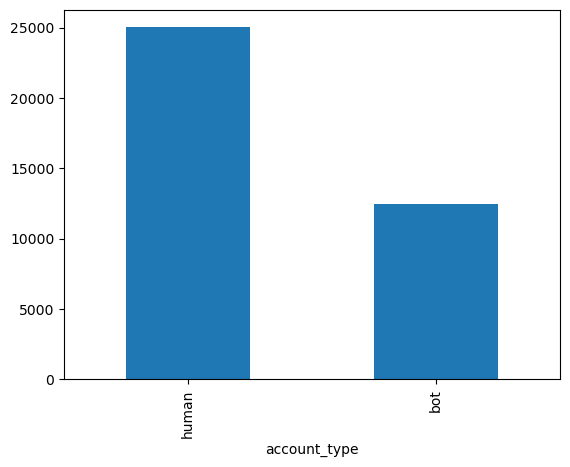

In [28]:
df['account_type'].value_counts().plot(kind='bar')

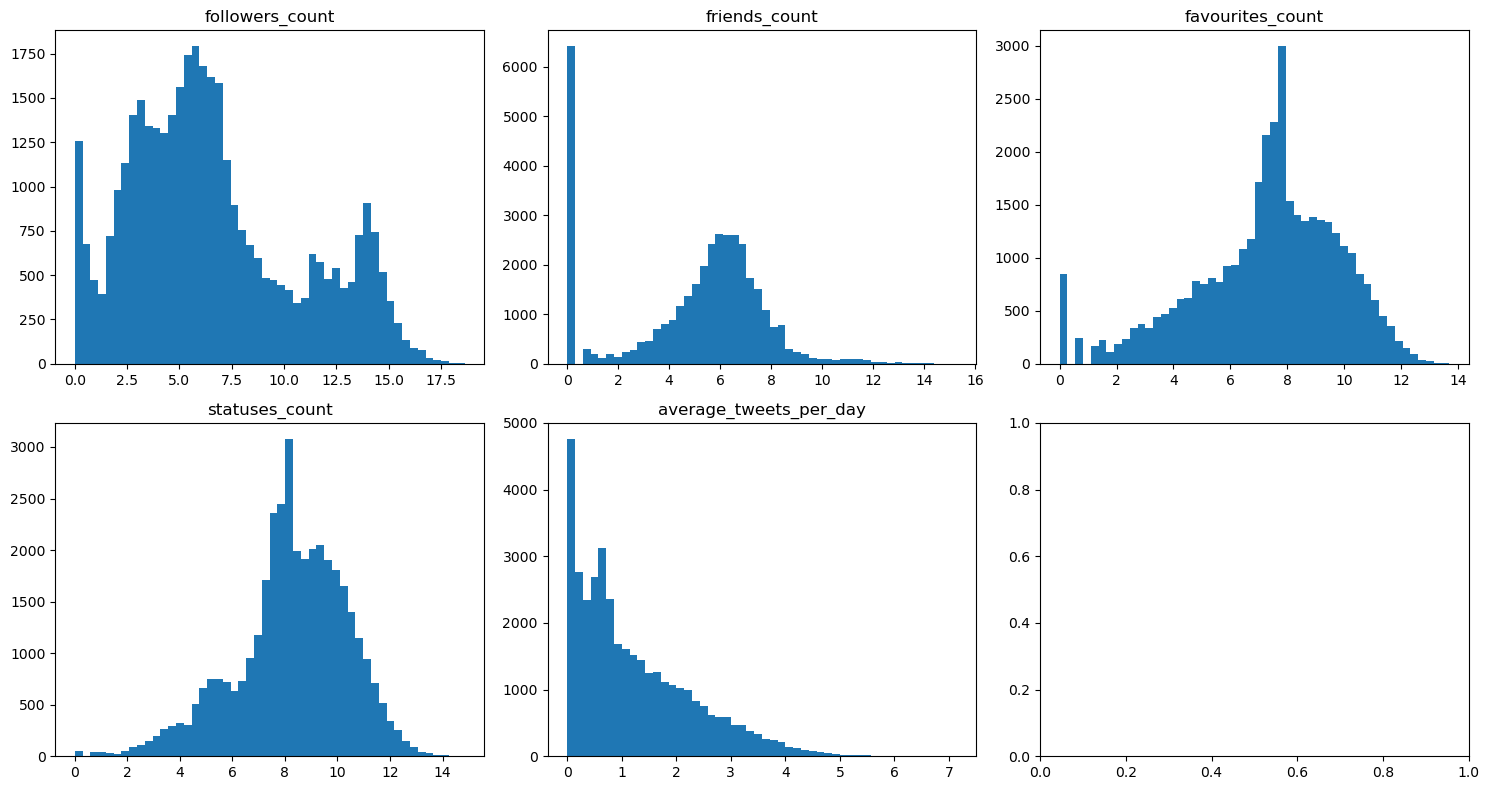

In [41]:
cols = ['followers_count','friends_count', 'favourites_count', 'statuses_count', 'average_tweets_per_day']
fig, axes = plt.subplots(2,3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), cols):
    ax.hist(np.log1p(df[col]), bins=50)
    ax.set_title(col)
plt.tight_layout()
plt.show()

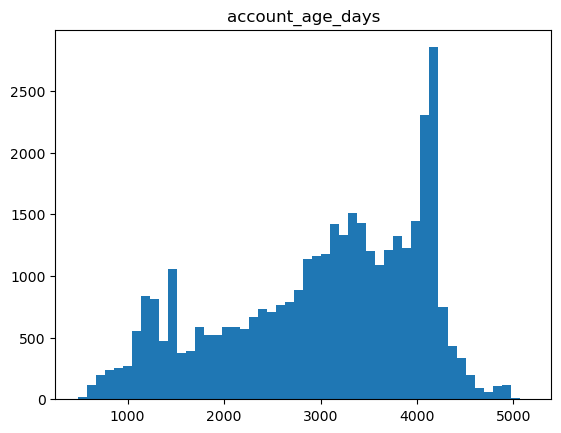

In [40]:
plt.hist(df['account_age_days'], bins=50)
plt.title('account_age_days')
plt.show()

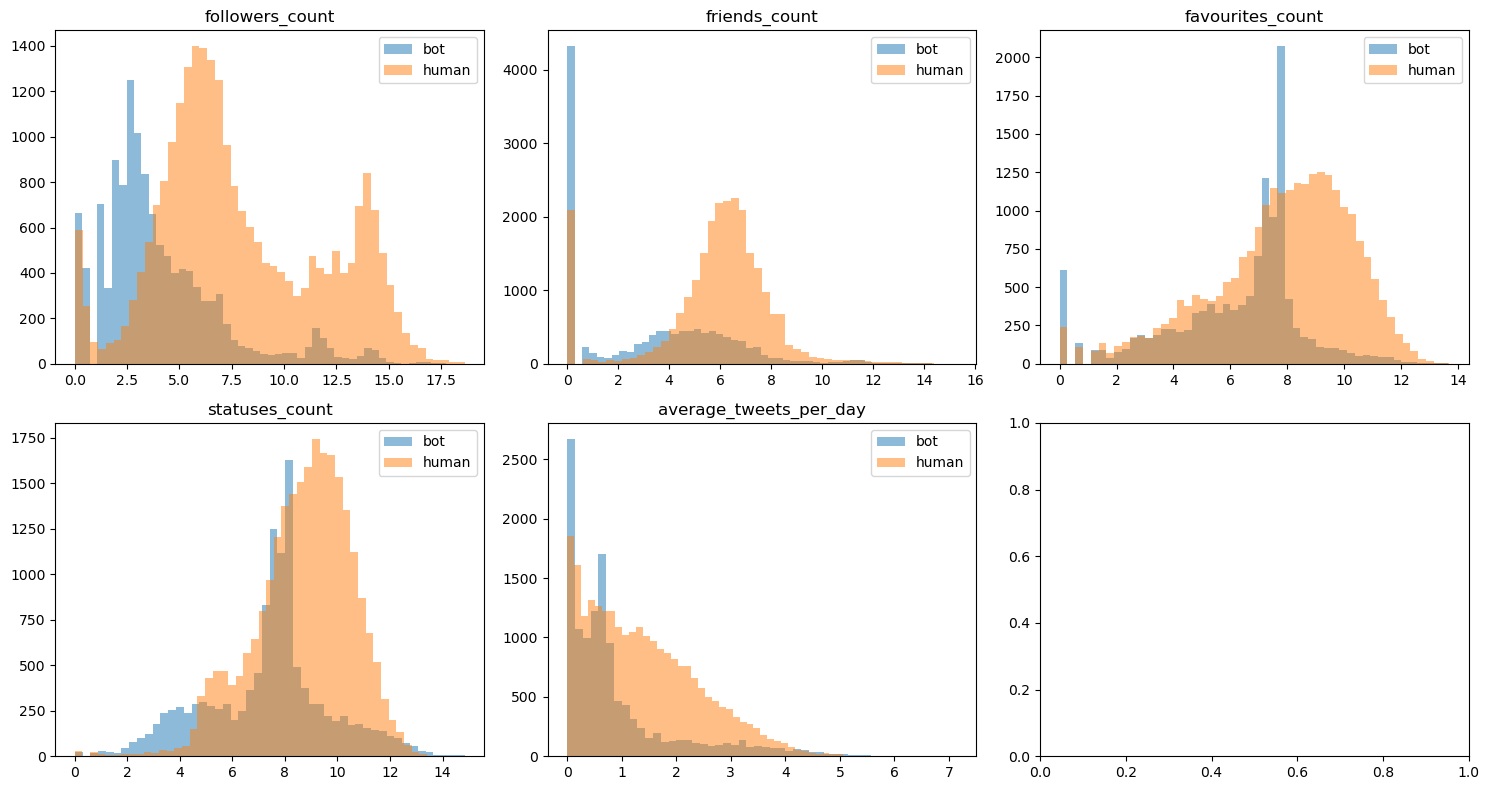

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), cols):
    for label, group in df.groupby('account_type'):
        ax.hist(np.log1p(group[col]), bins=50, alpha=0.5, label=label)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

### followers_count: bots have less followers. The disribuiotn of followers count for humans are better spread. good feature for seperating bots from humans.
### bots have a large peak at zero. Many bots don't follow anyone.good feature for seperating bots from humans.
### For favourites counts and statuses count, bots and humans have similar distribution.
### humans have higher freqency of tweets. 

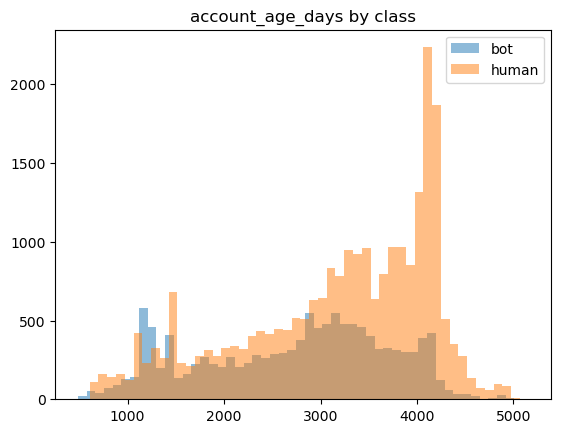

In [42]:
for label, group in df.groupby('account_type'):
    plt.hist(group['account_age_days'], bins=50, alpha=0.5, label=label)
plt.title('account_age_days by class')
plt.legend()
plt.show()

In [47]:
### bots peak around 1000-1200 days, humans have a larger peak at about 4000 days. Very old accounts are more human.

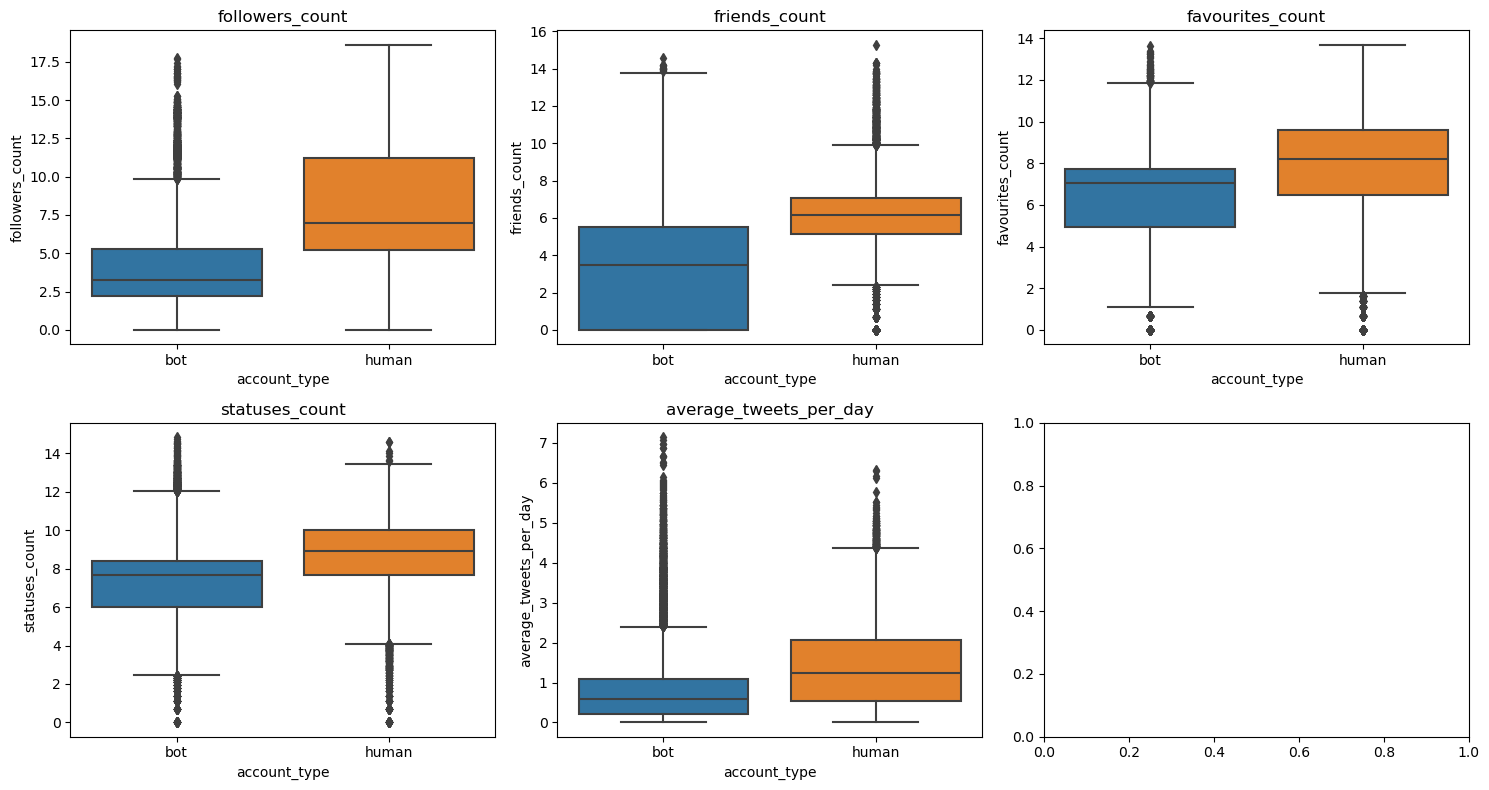

In [44]:
import seaborn as sns
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), cols):
    sns.boxplot(data=df, x='account_type', y=np.log1p(df[col]), ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [45]:
for col in ['default_profile', 'default_profile_image', 'geo_enabled', 'verified']:
    print(pd.crosstab(df[col], df['account_type'], normalize='index'))
    print()

account_type          bot     human
default_profile                    
False            0.215674  0.784326
True             0.492430  0.507570

account_type                bot     human
default_profile_image                    
False                  0.326518  0.673482
True                   0.686380  0.313620

account_type       bot     human
geo_enabled                     
False         0.476843  0.523157
True          0.159044  0.840956

account_type       bot     human
verified                        
False         0.405159  0.594841
True          0.041849  0.958151



<Axes: >

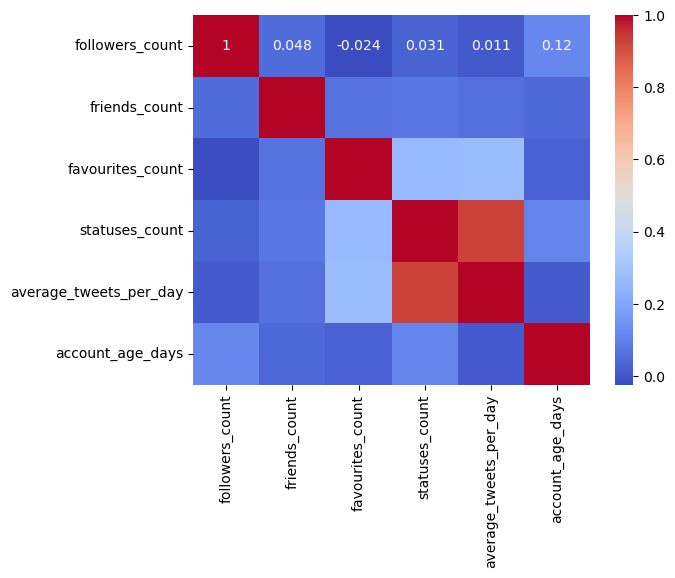

In [46]:
sns.heatmap(df[cols + ['account_age_days']].corr(), annot=True, cmap='coolwarm')